In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

In [2]:
dataname = '/kaggle/input/public-ai-risk-repository-v4-2025-12-15/PUBLIC AI Risk Repository V4 2025-12-15.csv'
df = pd.read_csv(dataname)
df.head(3)
df.describe()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1395 entries, 0 to 1394
Data columns (total 10 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Ev_ID                               1395 non-null   object
 1   Document_ID                         1395 non-null   object
 2   Category level                      1395 non-null   object
 3   Risk category                       1395 non-null   object
 4   Risk Subcategory                    1059 non-null   object
 5   Description_Clean                   1253 non-null   object
 6   CausalTax_Entity (Synced)           1393 non-null   object
 7   CausalTax_Intent (Synced)           1393 non-null   object
 8   CausalTax_Timing (Synced)           1393 non-null   object
 9   DocNameAuthYear (from Document_ID)  1395 non-null   object
dtypes: object(10)
memory usage: 109.1+ KB


In [3]:
print("\n Data types: ", df.dtypes, "\n")
print("\n Missing values: \n", df.isnull().sum())
print("\n Missing data: \n", df.isna().any())
print("\n Dupplicate data: ", df.duplicated().sum())


 Data types:  Ev_ID                                 object
Document_ID                           object
Category level                        object
Risk category                         object
Risk Subcategory                      object
Description_Clean                     object
CausalTax_Entity (Synced)             object
CausalTax_Intent (Synced)             object
CausalTax_Timing (Synced)             object
DocNameAuthYear (from Document_ID)    object
dtype: object 


 Missing values: 
 Ev_ID                                   0
Document_ID                             0
Category level                          0
Risk category                           0
Risk Subcategory                      336
Description_Clean                     142
CausalTax_Entity (Synced)               2
CausalTax_Intent (Synced)               2
CausalTax_Timing (Synced)               2
DocNameAuthYear (from Document_ID)      0
dtype: int64

 Missing data: 
 Ev_ID                                 False
Docu

In [4]:
# Handling missing data
rows_with_missing_data = df[df.isnull().any(axis = 1)]
print("\n Rows with missing data: \n", rows_with_missing_data.head(5))



 Rows with missing data: 
       Ev_ID     Document_ID Category level                  Risk category  \
1  02.08.00         Cui2024  Risk Category   Toxicity and Bias Tendencies   
3  03.01.00       Cunha2023  Risk Category                 Broken systems   
4  04.02.00        Deng2023  Risk Category  Unfairness and Discrimination   
5  05.01.00  Hagendorff2024  Risk Category                Fairness - Bias   
6  06.03.00   Hogenhout2021  Risk Category                 Discrimination   

  Risk Subcategory                                  Description_Clean  \
1              NaN  Extensive data collection in LLMs brings toxic...   
3              NaN  These are the most mentioned cases. They refer...   
4              NaN  Social bias is an unfairly negative attitude t...   
5              NaN  Fairness is, by far, the most discussed issue ...   
6              NaN  When AI is not carefully designed, it can disc...   

  CausalTax_Entity (Synced) CausalTax_Intent (Synced)  \
1            

In [5]:
# Filling missing data 'Risk category' with 'un-defined'
df.fillna("un-defined",inplace = True)
# df.method({col: value}, inplace=True)

In [6]:
# Handling missing value
rows_with_missing_values = df[df.isna().any(axis = 1)]
print("\n Rows with missing values: \n", rows_with_missing_values.head(3))
# df.fillna("Risk category: un-defined",inplace = True)


 Rows with missing values: 
 Empty DataFrame
Columns: [Ev_ID, Document_ID, Category level, Risk category, Risk Subcategory, Description_Clean, CausalTax_Entity (Synced), CausalTax_Intent (Synced), CausalTax_Timing (Synced), DocNameAuthYear (from Document_ID)]
Index: []


In [7]:
print(rows_with_missing_values.shape)
print(rows_with_missing_data.shape)

(0, 10)
(457, 10)


In [8]:
rows_with_missing_data = df[df.isnull().any(axis = 1)]
print("\n Rows with missing data: ", rows_with_missing_data.head(3))


 Rows with missing data:  Empty DataFrame
Columns: [Ev_ID, Document_ID, Category level, Risk category, Risk Subcategory, Description_Clean, CausalTax_Entity (Synced), CausalTax_Intent (Synced), CausalTax_Timing (Synced), DocNameAuthYear (from Document_ID)]
Index: []


In [9]:
df.head(3)

,Ev_ID,Document_ID,Category level,Risk category,Risk Subcategory,Description_Clean,CausalTax_Entity (Synced),CausalTax_Intent (Synced),CausalTax_Timing (Synced),DocNameAuthYear (from Document_ID)
0,02.01.01,Cui2024,Risk Sub-Category,Harmful Content,Bias,The training datasets of LLMs may contain bias...,AI,Unintentional,Other,"Risk Taxonomy, Mitigation, and Assessment Benc..."
1,02.08.00,Cui2024,Risk Category,Toxicity and Bias Tendencies,un-defined,Extensive data collection in LLMs brings toxic...,Human,Unintentional,Pre-deployment,"Risk Taxonomy, Mitigation, and Assessment Benc..."
2,02.08.02,Cui2024,Risk Sub-Category,Toxicity and Bias Tendencies,Biased Training Data,"Compared with the definition of toxicity, the ...",AI,Unintentional,Pre-deployment,"Risk Taxonomy, Mitigation, and Assessment Benc..."


In [10]:
features = df.columns
print(features)

Index(['Ev_ID', 'Document_ID', 'Category level', 'Risk category',
       'Risk Subcategory', 'Description_Clean', 'CausalTax_Entity (Synced)',
       'CausalTax_Intent (Synced)', 'CausalTax_Timing (Synced)',
       'DocNameAuthYear (from Document_ID)'],
      dtype='object')


### Cluster risk 
 

In [11]:
# Convert data to numeric values
# print(df.info())

unique_value = df.nunique()
print(unique_value)
# identify and analyze categorical variables 
print(df['Risk category'].value_counts(normalize = True))

Ev_ID                                 1392
Document_ID                             72
Category level                           2
Risk category                          457
Risk Subcategory                      1020
Description_Clean                     1240
CausalTax_Entity (Synced)                5
CausalTax_Intent (Synced)                5
CausalTax_Timing (Synced)                5
DocNameAuthYear (from Document_ID)      72
dtype: int64
Risk category
Sources of systemic risks from general-purpose AI     0.034409
Model Evaluations                                     0.012186
Ethical and social risks                              0.010753
Systemic Risks                                        0.010036
Malicious Uses                                        0.010036
                                                        ...   
Value Chain and Component Integration                 0.000717
Intelligibility                                       0.000717
Fairness - Bias                        

In [12]:
# NLP clustering of risk subcategory labels
labels = df["Risk Subcategory"].dropna().unique()
print("Total labels: ", len(labels))




Total labels:  1020


<Axes: xlabel='CausalTax_Intent (Synced)', ylabel='CausalTax_Entity (Synced)'>

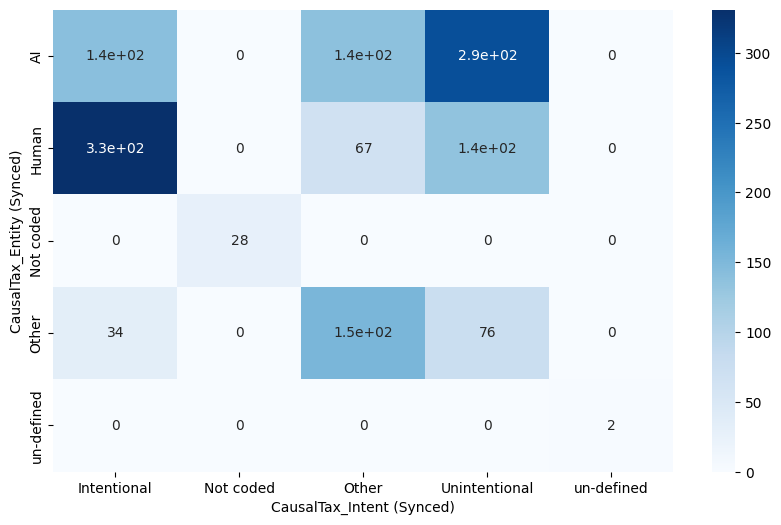

In [13]:
correlation_data = df.groupby(["CausalTax_Entity (Synced)","CausalTax_Intent (Synced)"])["Risk category"].count().unstack(fill_value = 0)

# plot heatmap
plt.figure(figsize = (10,6))
sns.heatmap(correlation_data, annot = True, cmap = "Blues")


## Process categorical data
Keep only the top N frequent categories

count    457.000000
mean       3.052516
std        3.438922
min        1.000000
25%        1.000000
50%        2.000000
75%        4.000000
max       48.000000
Name: count, dtype: float64
Risk categories appearing only once:  219
Risk categories appearing < 5 times:  355


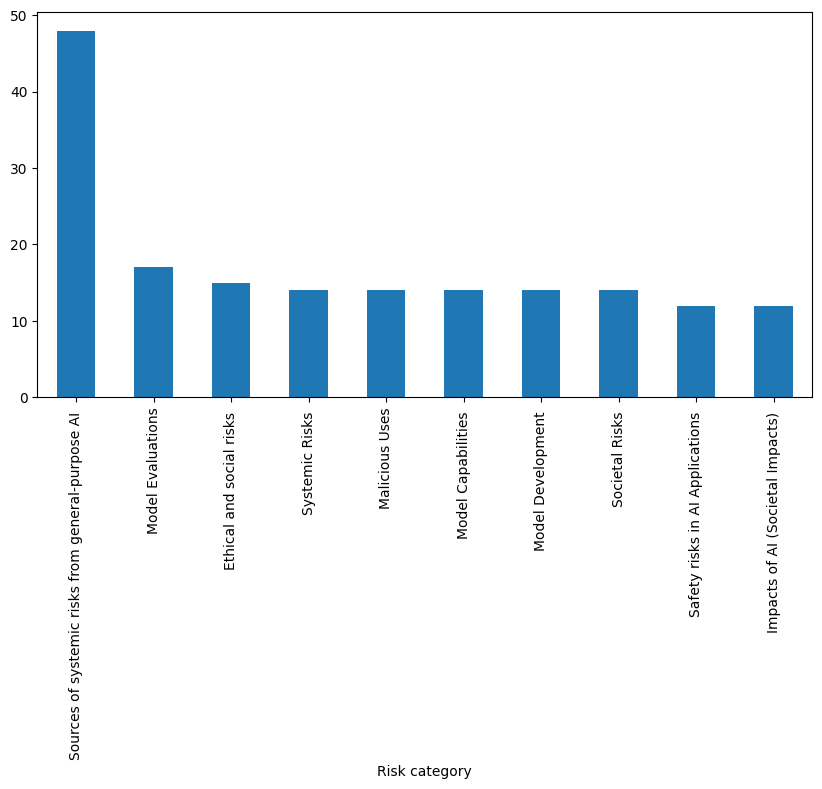

In [14]:
# Count risks
risk_counts = df["Risk category"].value_counts()
print(risk_counts.describe())

# Identify rare categories
rare_risk = (risk_counts == 1).sum()
print("Risk categories appearing only once: ", rare_risk)

# Risk appearing fewer than 5 times
rare_5_risk = (risk_counts <5).sum()
print("Risk categories appearing < 5 times: ", rare_5_risk )

top_n = 10
top_risk = risk_counts.head(top_n).plot(kind = "bar", figsize = (10,5))


 Count Risk: 
 Risk_category_clean
Other                                                 1221
Sources of systemic risks from general-purpose AI       48
Model Evaluations                                       17
Ethical and social risks                                15
Systemic Risks                                          14
Model Development                                       14
Malicious Uses                                          14
Model Capabilities                                      14
Societal Risks                                          14
Safety risks in AI Applications                         12
Impacts of AI (Societal Impacts)                        12
Name: count, dtype: int64
Risk category
Sources of systemic risks from general-purpose AI     3.440860
Model Evaluations                                     1.218638
Ethical and social risks                              1.075269
Systemic Risks                                        1.003584
Malicious Uses         

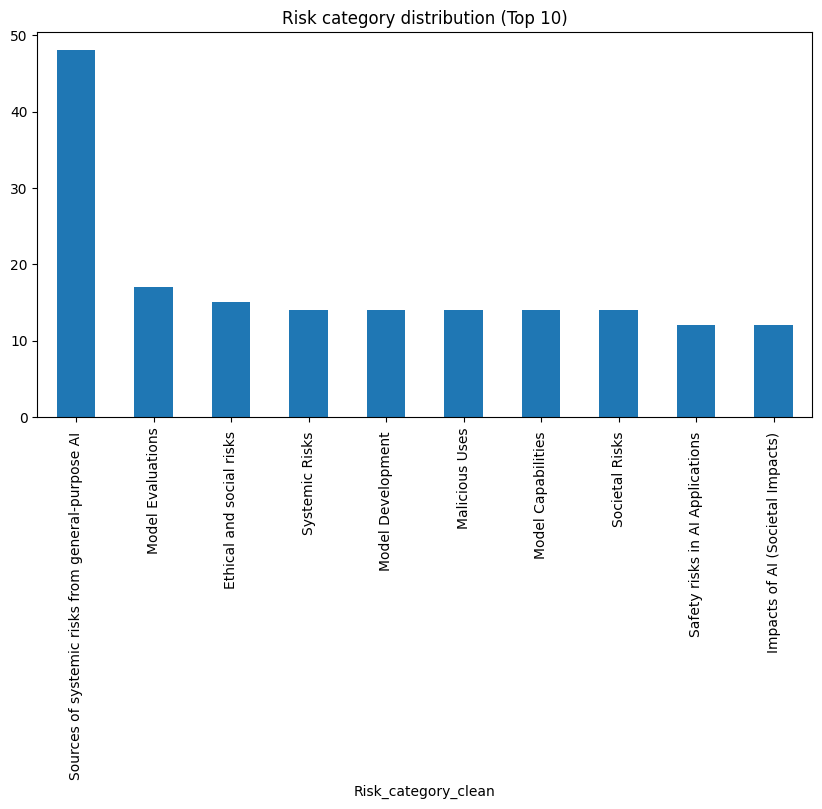

In [15]:
# Group rare categories into others
topn = risk_counts.head(top_n).index
df["Risk_category_clean"] = df["Risk category"].apply(
    lambda x: x if x in topn else "Other"
)
count_risk = df["Risk_category_clean"].value_counts()
risk_percent = df["Risk category"].value_counts(normalize = True)*100
print("\n Count Risk: \n", count_risk)
print(risk_percent.head(10))

# plot clean distribution
print(df["Risk_category_clean"].value_counts().iloc[1:])
df["Risk_category_clean"].value_counts().iloc[1:].plot(kind = "bar", figsize = (10,5))
plt.title("Risk category distribution (Top 10)")
plt.show()

Risk category
Sources of systemic risks from general-purpose AI     48
Model Evaluations                                     17
Ethical and social risks                              15
Systemic Risks                                        14
Malicious Uses                                        14
Model Capabilities                                    14
Model Development                                     14
Societal Risks                                        14
Safety risks in AI Applications                       12
Impacts of AI (Societal Impacts)                      12
Name: count, dtype: int64


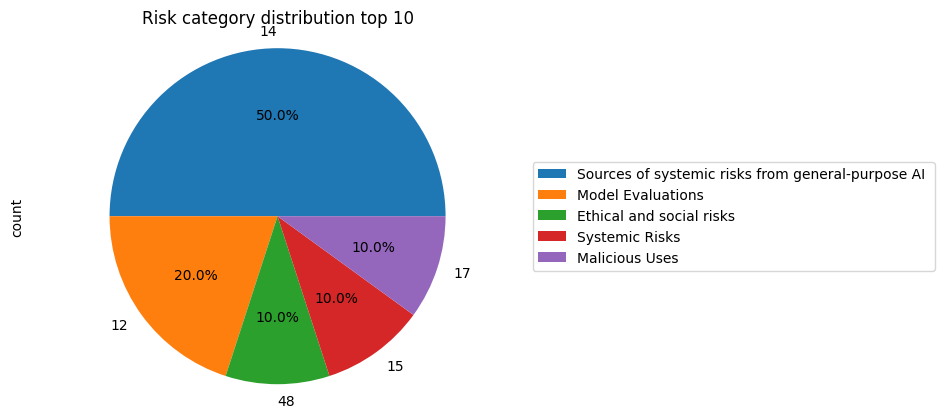

In [16]:
# plot a pie chart of 10 top risk
risk_counts_ten = df["Risk category"].value_counts().head(10)
print(risk_counts_ten)
risk_counts_ten.value_counts().plot.pie(autopct = '%1.1f%%', legend=True,title = "Risk category distribution top 10")
plt.legend(labels = risk_counts_ten.index, loc = 'center left', bbox_to_anchor = (1, 0.5))
plt.axis('equal')
plt.show()


## Causal of risk analysis

In [17]:
pd.crosstab(df["Category level"], df["CausalTax_Intent (Synced)"])

CausalTax_Intent (Synced),Intentional,Not coded,Other,Unintentional,un-defined
Category level,,,,,
Risk Category,83,10,110,134,2
Risk Sub-Category,422,18,248,368,0


In [18]:
pd.crosstab(df["Category level"], df["CausalTax_Entity (Synced)"])

CausalTax_Entity (Synced),AI,Human,Not coded,Other,un-defined
Category level,,,,,
Risk Category,161,95,10,71,2
Risk Sub-Category,408,438,18,192,0


In [19]:
pd.crosstab(df["CausalTax_Intent (Synced)"], df["CausalTax_Entity (Synced)"])

CausalTax_Entity (Synced),AI,Human,Not coded,Other,un-defined
CausalTax_Intent (Synced),,,,,
Intentional,140,331,0,34,0
Not coded,0,0,28,0,0
Other,138,67,0,153,0
Unintentional,291,135,0,76,0
un-defined,0,0,0,0,2


In [20]:
pd.crosstab(df["Risk_category_clean"], df["CausalTax_Entity (Synced)"])

CausalTax_Entity (Synced),AI,Human,Not coded,Other,un-defined
Risk_category_clean,,,,,
Ethical and social risks,3,11,0,1,0
Impacts of AI (Societal Impacts),2,10,0,0,0
Malicious Uses,0,10,0,4,0
Model Capabilities,13,0,1,0,0
Model Development,0,10,1,3,0
Model Evaluations,3,8,0,6,0
Other,525,440,26,228,2
Safety risks in AI Applications,1,8,0,3,0
Societal Risks,0,11,0,3,0


In [21]:
pd.crosstab(df["Risk_category_clean"], df["CausalTax_Intent (Synced)"])

CausalTax_Intent (Synced),Intentional,Not coded,Other,Unintentional,un-defined
Risk_category_clean,,,,,
Ethical and social risks,9,0,0,6,0
Impacts of AI (Societal Impacts),8,0,3,1,0
Malicious Uses,14,0,0,0,0
Model Capabilities,11,1,1,1,0
Model Development,5,1,0,8,0
Model Evaluations,1,0,5,11,0
Other,421,26,330,442,2
Safety risks in AI Applications,7,0,1,4,0
Societal Risks,12,0,1,1,0
